# Logistic regression tutorial

In this tutorial, we solve a *binary classification* problem with logistic regression, trained by gradient descent.

We have a training set of $N$ inputs with two features each, $\mathbf{x}_n \in \mathbb{R}^D$ with $D = 2$, and one label each, $y_n \in \{0, 1\}$, for $n = 1, \dots, N$.
Logistic regression maps an input to the probability that it belongs to class 1:

$$\hat{y}_n = p(y_n = 1 \mid \mathbf{x}_n, \boldsymbol{\theta}) = \sigma(w_1 x_{n,1} + w_2 x_{n,2} + b), \qquad \sigma(z) = \frac{1}{1 + \mathrm{e}^{-z}},$$

where the weights $w_1, w_2$ and the bias $b$ are the learnable parameters, and $\sigma$ is the *sigmoid* function.

As in lecture 3, we append a $1$ to every input.
The bias then becomes the last entry of a single parameter vector and is treated like any other weight:

$$\boldsymbol{\theta} = \begin{pmatrix} w_1 \\ w_2 \\ b \end{pmatrix} \in \mathbb{R}^{D + 1}, \qquad
\tilde{\mathbf{x}}_n = \begin{pmatrix} x_{n,1} \\ x_{n,2} \\ 1 \end{pmatrix} \in \mathbb{R}^{D + 1}, \qquad
\hat{y}_n = \sigma(\boldsymbol{\theta}^\top \tilde{\mathbf{x}}_n) \in (0, 1).$$

We call $\tilde{\mathbf{x}}_n$ a *bias-augmented feature vector*.
Stacking all of them row by row gives the *bias-augmented data matrix* $\tilde{\mathbf{X}}$, and the labels go into a label vector $\mathbf{y}$:

$$\tilde{\mathbf{X}} = \begin{pmatrix}
x_{1,1} & x_{1,2} & 1\\
x_{2,1} & x_{2,2} & 1\\
\vdots & \vdots & \vdots\\
x_{N,1} & x_{N,2} & 1
\end{pmatrix} \in \mathbb{R}^{N \times (D + 1)}, \qquad
\mathbf{y} = \begin{pmatrix} y_1 \\ y_2 \\ \vdots \\ y_N \end{pmatrix} \in \{0, 1\}^N.$$

The labels form a vector, not a matrix: binary classification has a single output per example, the probability of class 1.
This is why we drop the output axis of size $K$ that the linear regression tutorial carried along (with $K = 1$).
It comes back in the multiclass tutorial, where $K$ classes need $K$ probabilities per example.

With these, all predictions come out of a single matrix-vector product, without a loop over the examples:

$$\hat{\mathbf{y}} = \sigma(\tilde{\mathbf{X}} \boldsymbol{\theta}) \in (0, 1)^N,$$

where the sigmoid is applied element-wise.

As objective, we use the binary cross-entropy (BCE) between the labels and the predicted probabilities:

$$J(\boldsymbol{\theta}) = -\frac{1}{N} \sum_{n=1}^N \Big[ y_n \ln(\hat{y}_n) + (1 - y_n) \ln(1 - \hat{y}_n) \Big].$$

It is small when the predicted probabilities are close to their labels.
Like the predictions, it can be written without the sum over the examples, since the sums are inner products:

$$J(\boldsymbol{\theta}) = -\frac{1}{N} \Big[ \mathbf{y}^\top \ln(\hat{\mathbf{y}}) + (\mathbf{1} - \mathbf{y})^\top \ln(\mathbf{1} - \hat{\mathbf{y}}) \Big],$$

where $\mathbf{1}$ is the vector of all ones and the logarithm is applied element-wise.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap


# Set Matplotlib backend to `inline` to display the figure below the cell that produced it
%matplotlib inline

In [2]:
def sigmoid(z):
    """Evaluate the sigmoid function element-wise.

    Args:
        z: Array of arbitrary shape.

    Returns:
        The sigmoid of each entry, of the same shape as z.
    """
    return 1 / (1 + np.exp(-z))


def logistic_model(X_tilde, theta):
    """Evaluate the logistic regression model.

    Args:
        X_tilde: Bias-augmented data matrix of shape (N, D + 1).
        theta: Parameter vector of shape (D + 1,).

    Returns:
        The predicted probabilities of class 1, of shape (N,).
    """
    return sigmoid(X_tilde @ theta)

## 1. Dataset creation

Let's draw some samples for training and test.
Each class has its own Gaussian, which models imperfect observations of two prototypes.

In [3]:
# Sizes (see the notation of lecture 1)
D = 2  # input features per example
N_per_class = 100  # examples per class, so each set has 2 * N_per_class examples

rng = np.random.default_rng(42)


def get_dataset(N=N_per_class, mu0=(0, 0), mu1=(2, 2), var=0.5):
    """Create a dataset by drawing N samples per class from two Gaussians.

    Args:
        N: Number of examples per class.
        mu0: Center of class 0.
        mu1: Center of class 1.
        var: Variance of both Gaussians along each feature.

    Returns:
        The data matrix of shape (2 N, D) and the label vector of shape (2 N,).
    """
    cov = var * np.eye(D)

    # Class 0 samples
    X0 = rng.multivariate_normal(mu0, cov, N)
    y0 = np.zeros(N)

    # Class 1 samples
    X1 = rng.multivariate_normal(mu1, cov, N)
    y1 = np.ones(N)

    return np.concatenate([X0, X1]), np.concatenate([y0, y1])


def augment(X):
    """Append the column of ones that implements the bias term (see lecture 3).

    Args:
        X: Data matrix of shape (N, D).

    Returns:
        The bias-augmented data matrix, of shape (N, D + 1).
    """
    return np.concatenate([X, np.ones((X.shape[0], 1))], axis=1)


def plot_data(X, y, xlim=(-2, 3), ylim=(-2, 3), xlabel=r"$x_1$", ylabel=r"$x_2$", legend=True):
    """Draw a scatter plot of the data, colored by label.

    Args:
        X: Data matrix of shape (N, D).
        y: Label vector of shape (N,).
        xlim: Range of the horizontal axis.
        ylim: Range of the vertical axis.
        xlabel: Label of the horizontal axis.
        ylabel: Label of the vertical axis.
        legend: Whether to add a legend (off for all but one panel of a grid).
    """
    plt.scatter(X[y == 0, 0], X[y == 0, 1], label="class 0")
    plt.scatter(X[y == 1, 0], X[y == 1, 1], label="class 1")
    plt.xlim(xlim)
    plt.ylim(ylim)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    if legend:
        plt.legend(loc="upper left")

X_train has shape (200, 2), y_train has shape (200,)
X_test has shape (200, 2), y_test has shape (200,)
After augmentation, X_tilde_train has shape (200, 3)


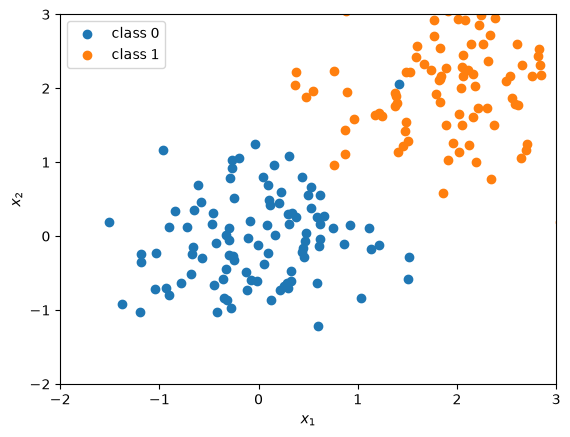

In [4]:
# Draw the training and test set
X_train, y_train = get_dataset()
X_test, y_test = get_dataset()

# Append the column of ones to both data matrices
X_tilde_train, X_tilde_test = augment(X_train), augment(X_test)

print(f"X_train has shape {X_train.shape}, y_train has shape {y_train.shape}")
print(f"X_test has shape {X_test.shape}, y_test has shape {y_test.shape}")
print(f"After augmentation, X_tilde_train has shape {X_tilde_train.shape}")

# Plot the training samples
plot_data(X_train, y_train)

**Remark**:
As you can see, we sample the data from two Gaussians.
In a real machine learning problem, however, we have **no access** to the **data generation** process: think of the hidden process that produces images or speech signals.
The learning algorithm only sees the samples, never the process that produced them.

## 2. Training with gradient descent

To perform gradient descent, we need the gradient of the objective (see lecture 3).
It is *error times input*:

$$\nabla_{\boldsymbol{\theta}} J(\boldsymbol{\theta}) = \frac{1}{N} \sum_{n=1}^N \big( \hat{y}_n - y_n \big)\, \tilde{\mathbf{x}}_n = \frac{1}{N} \tilde{\mathbf{X}}^\top \big( \hat{\mathbf{y}} - \mathbf{y} \big).$$

We use the fully vectorized form on the right.
Remember that in machine learning we avoid *for loops* as much as possible when implementing a model: loops are slow, while matrix multiplications are easily parallelized.

One update of the parameters goes into a function, so that the training loop below only has to call it once per epoch.

In [5]:
def bce(y, y_hat):
    """Return the mean binary cross-entropy between labels and predictions.

    Args:
        y: Label vector of shape (N,).
        y_hat: Vector of predicted probabilities of class 1, of shape (N,).

    Returns:
        The mean binary cross-entropy (a scalar).
    """
    # `np.log` is the natural logarithm
    return -(y * np.log(y_hat) + (1 - y) * np.log(1 - y_hat)).mean()


def accuracy(y, y_hat):
    """Return the fraction of examples that are classified correctly.

    Args:
        y: Label vector of shape (N,).
        y_hat: Vector of predicted probabilities of class 1, of shape (N,).

    Returns:
        The accuracy, a number between 0 and 1.
    """
    # The predicted class is 1 where the predicted probability exceeds 0.5
    predicted_class = (y_hat > 0.5).astype(float)
    return (predicted_class == y).mean()


def gd_step(X_tilde, y, theta, lr):
    """Perform one gradient descent step on the binary cross-entropy.

    Args:
        X_tilde: Bias-augmented data matrix of the training set, of shape (N, D + 1).
        y: Label vector of the training set, of shape (N,).
        theta: Current parameter vector of shape (D + 1,).
        lr: Learning rate (a scalar).

    Returns:
        The updated parameter vector, of shape (D + 1,).
    """
    y_hat = logistic_model(X_tilde, theta)
    grad = X_tilde.T @ (y_hat - y) / y.size
    return theta - lr * grad


# Blue where class 0 is predicted, orange where class 1 is, white where the model is undecided.
# The two pale tones are the light variants of the `tab:blue` and `tab:orange` of the scatter
# plot, so that the data points stay clearly visible on top of the shading.
probability_cmap = LinearSegmentedColormap.from_list(
    "probability", ["#aec7e8", "white", "#ffbb78"]
)


def plot_boundary(theta, xlim=(-2, 3), ylim=(-2, 3)):
    """Shade the plane by the probability that logistic regression predicts for class 1.

    The dashed line is the decision boundary, where the predicted probability is 0.5.
    The width of the pale band around it shows how confident the model is.

    Args:
        theta: Parameter vector of shape (D + 1,).
        xlim: Range of the horizontal axis.
        ylim: Range of the vertical axis.
    """
    x1, x2 = np.meshgrid(np.linspace(*xlim, 200), np.linspace(*ylim, 200))
    p = logistic_model(augment(np.column_stack([x1.ravel(), x2.ravel()])), theta)
    p = p.reshape(x1.shape)
    plt.pcolormesh(x1, x2, p, cmap=probability_cmap, vmin=0, vmax=1, shading="gouraud")
    plt.contour(x1, x2, p, levels=[0.5], colors="k", linewidths=1, linestyles="--")

epoch    0: train loss = 0.8107, test loss = 0.7932
epoch    1: train loss = 0.5776, test loss = 0.5660
epoch    2: train loss = 0.4307, test loss = 0.4261
epoch    3: train loss = 0.3410, test loss = 0.3424
epoch    5: train loss = 0.2453, test loss = 0.2552
epoch    8: train loss = 0.1810, test loss = 0.1983
epoch   12: train loss = 0.1415, test loss = 0.1645
epoch   20: train loss = 0.1071, test loss = 0.1363
epoch   35: train loss = 0.0828, test loss = 0.1174
epoch   60: train loss = 0.0680, test loss = 0.1067
epoch  150: train loss = 0.0551, test loss = 0.0985
epoch  600: train loss = 0.0500, test loss = 0.0969


after 3000 epochs: train loss = 0.0498, test loss = 0.0974
                    train accuracy = 0.9900, test accuracy = 0.9550
w1 = 3.7064, w2 = 3.9616, b = -7.2070


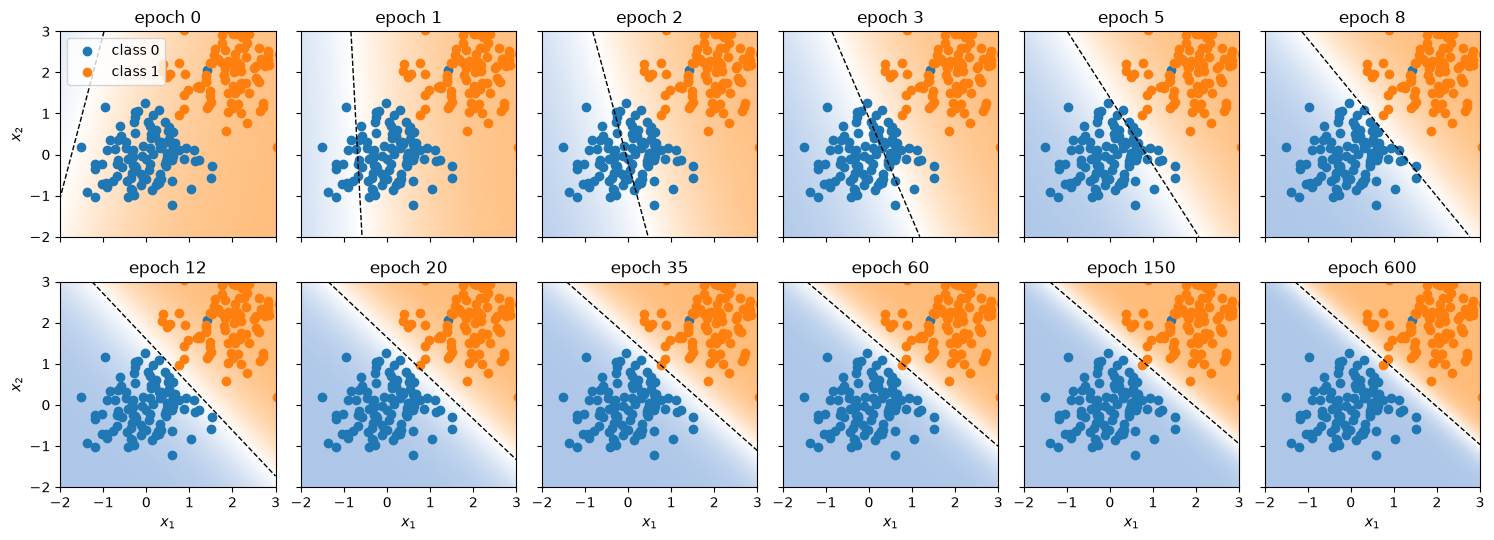

In [6]:
# Initial values (deliberately poor)
theta = np.array([0.5, -0.5, 2.0])

# Hyperparameters
N_epochs = 3000
lr = 2.0

# The boundary swings in the first epochs and then only sharpens, so we report and snapshot it
# on a roughly doubling schedule, one entry per panel of the grid below
report_epochs = [0, 1, 2, 3, 5, 8, 12, 20, 35, 60, 150, 600]

# The snapshots share their axes, so that the panels can be compared directly
fig, axes = plt.subplots(2, 6, figsize=(15, 5.5), sharex=True, sharey=True)
panels = axes.flatten()

train_loss, train_acc = [], []
test_loss, test_acc = [], []
for epoch in range(N_epochs):
    # one gradient descent update
    theta = gd_step(X_tilde_train, y_train, theta, lr)

    # compute the training and test metrics (just to monitor)
    y_hat_train = logistic_model(X_tilde_train, theta)
    y_hat_test = logistic_model(X_tilde_test, theta)
    train_loss.append(bce(y_train, y_hat_train))
    test_loss.append(bce(y_test, y_hat_test))
    train_acc.append(accuracy(y_train, y_hat_train))
    test_acc.append(accuracy(y_test, y_hat_test))

    if epoch in report_epochs:
        print(f"epoch {epoch:4d}: train loss = {train_loss[-1]:.4f}, test loss = {test_loss[-1]:.4f}")

        # draw the training data with the current decision boundary into the next panel
        plt.sca(panels[report_epochs.index(epoch)])
        plot_boundary(theta)
        plot_data(X_train, y_train, legend=epoch == 0)
        plt.title(f"epoch {epoch}")

for panel in panels:
    panel.label_outer()  # keep the axis labels on the outer panels only
fig.tight_layout()

print(f"after {N_epochs} epochs: train loss = {train_loss[-1]:.4f}, test loss = {test_loss[-1]:.4f}")
print(f"{20 * ' '}train accuracy = {train_acc[-1]:.4f}, test accuracy = {test_acc[-1]:.4f}")
print(f"w1 = {theta[0]:.4f}, w2 = {theta[1]:.4f}, b = {theta[2]:.4f}")

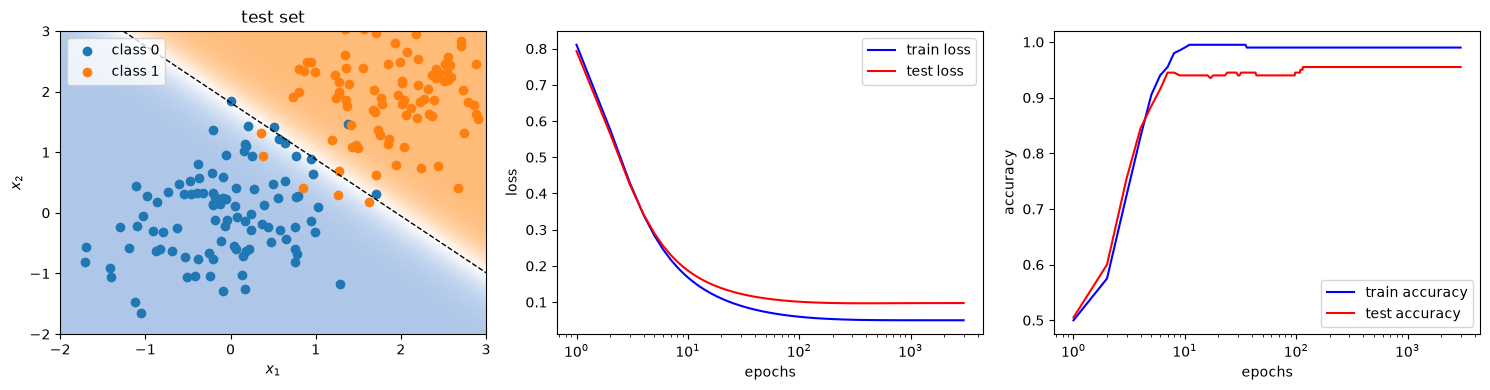

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Left: the test data with the final decision boundary
plt.sca(axes[0])  # `plot_boundary` and `plot_data` draw into the current axes
plot_boundary(theta)
plot_data(X_test, y_test)
axes[0].set_title("test set")

# Middle and right: the training curves, on a logarithmic epoch axis, as most of the
# progress happens in the first epochs
epochs = np.arange(1, N_epochs + 1)
for panel, (train, test, name) in zip(
    axes[1:], [(train_loss, test_loss, "loss"), (train_acc, test_acc, "accuracy")]
):
    panel.plot(epochs, train, color="blue", label=f"train {name}")
    panel.plot(epochs, test, color="red", label=f"test {name}")
    panel.set_xscale("log")
    panel.set_xlabel("epochs")
    panel.set_ylabel(name)
    panel.legend()

fig.tight_layout()

The algorithm starts from a bad solution, but gradient descent quickly improves it.
The final boundary also separates the test data well.
Note that the accuracy saturates long before the loss does: once the boundary lies between the two clouds, moving it further changes no prediction, while the objective keeps rewarding more confident probabilities.

## 3. Logistic regression with scikit-learn

Unlike linear regression, logistic regression has no closed-form solution (see lecture 3), so scikit-learn has to solve it iteratively as well.
Out of the box, however, it does not minimize our objective: it adds an L2 penalty on the weights $\mathbf{w} = (w_1, w_2)$, but not on the bias (lecture 2 introduces regularization, lecture 4 this penalty), and minimizes

$$\frac{1}{2} \lVert \mathbf{w} \rVert_2^2 + C \sum_{n=1}^N \big[ \text{BCE of example } n \big].$$

The argument `C` is the *inverse* regularization strength: it multiplies the loss rather than the penalty.
Dividing by $C N$ rescales the objective, which does not move its minimizer (see lecture 3), and brings it into the form we use:

$$-\frac{1}{N} \sum_{n=1}^N \Big[ y_n \ln(\hat{y}_n) + (1 - y_n) \ln(1 - \hat{y}_n) \Big] + \frac{\lambda}{2} \lVert \mathbf{w} \rVert_2^2, \qquad \lambda = \frac{1}{C N}.$$

So the default `C=1.0` really does regularize, while `C=np.inf` sets $\lambda = 0$ and leaves our plain BCE.
Let's compare the two solutions:

w1 = 3.7069, w2 = 3.9619, b = -7.2078


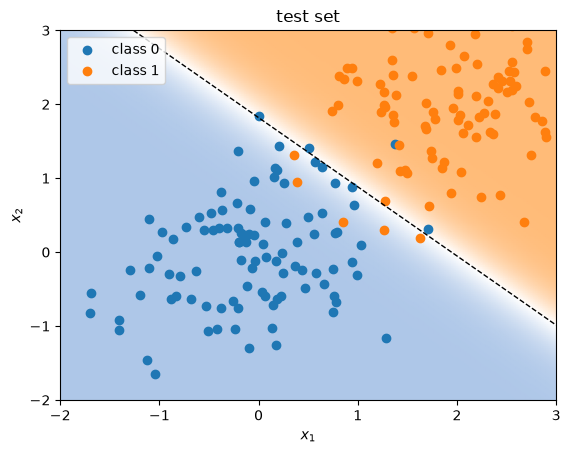

In [8]:
from sklearn.linear_model import LogisticRegression

# scikit-learn takes the data matrix without the column of ones and adds the intercept itself,
# and `C=np.inf` switches off its L2 penalty, so that it minimizes the same objective as we do
classifier = LogisticRegression(C=np.inf).fit(X_train, y_train)
theta_sklearn = np.concatenate([classifier.coef_[0], classifier.intercept_])
print(f"w1 = {theta_sklearn[0]:.4f}, w2 = {theta_sklearn[1]:.4f}, b = {theta_sklearn[2]:.4f}")

# Both now minimize the same objective, so both must land on the same parameters
# (up to the accuracy with which gradient descent approaches the minimum)
assert np.allclose(theta, theta_sklearn, rtol=1e-3), "scikit-learn found a different solution!"

# Plot the test data with the scikit-learn decision boundary
plot_boundary(theta_sklearn)
plot_data(X_test, y_test)
plt.title("test set");

## 4. Feature transformation

Logistic regression can only draw a *linear* decision boundary (see lecture 3), so it works well only if the two classes are (roughly) **linearly separable**.
Unfortunately, this is not the case in many machine learning problems.
We can, however, transform the features with a function $\phi(\mathbf{x})$ and hope that this improves their separability.

Let's look at an example.
We need a harder dataset than the one above, so we draw the samples from two concentric ellipses and add noise to model uncertainty in the observations.

In [9]:
def ellipse_samples(N, u=0.0, v=0.0, a=2.0, b=1.5, sigma=0.3):
    """Draw N noisy points from an ellipse.

    Args:
        N: Number of points to sample.
        u: Horizontal position of the center.
        v: Vertical position of the center.
        a: Radius along the horizontal axis.
        b: Radius along the vertical axis.
        sigma: Standard deviation of the additive Gaussian noise.

    Returns:
        The sampled points, of shape (N, D).
    """
    t = rng.uniform(low=0.0, high=2 * np.pi, size=N)
    x1 = u + a * np.cos(t) + sigma * rng.standard_normal(N)
    x2 = v + b * np.sin(t) + sigma * rng.standard_normal(N)
    return np.stack([x1, x2], axis=1)


def get_dataset_ellipses(N=N_per_class):
    """Create a dataset by drawing N samples per class from two concentric ellipses.

    Args:
        N: Number of examples per class.

    Returns:
        The data matrix of shape (2 N, D) and the label vector of shape (2 N,).
    """
    # Class 0 samples: the outer ellipse
    X0 = ellipse_samples(N, a=2.0, b=1.5)
    y0 = np.zeros(N)

    # Class 1 samples: the inner ellipse
    X1 = ellipse_samples(N, a=0.5, b=0.1)
    y1 = np.ones(N)

    return np.concatenate([X0, X1]), np.concatenate([y0, y1])

We can now draw the new dataset and plot it:

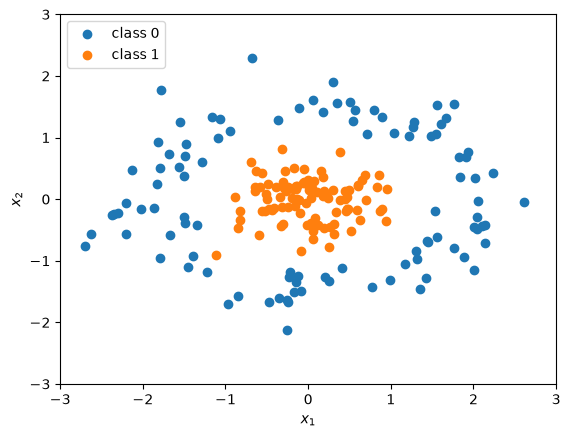

In [10]:
# Draw the training and test set
X_train, y_train = get_dataset_ellipses()
X_test, y_test = get_dataset_ellipses()

# Plot the training samples (the ellipses need a wider range than the Gaussians)
plot_data(X_train, y_train, xlim=(-3, 3), ylim=(-3, 3))

As you can see, the two classes are not linearly separable in this case.
If we apply logistic regression to this data directly, it does not find a meaningful solution:

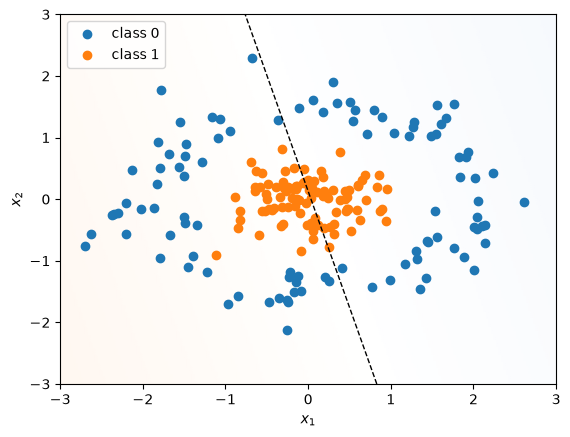

In [11]:
classifier = LogisticRegression(C=np.inf).fit(X_train, y_train)
theta_sklearn = np.concatenate([classifier.coef_[0], classifier.intercept_])

plot_boundary(theta_sklearn, xlim=(-3, 3), ylim=(-3, 3))
plot_data(X_train, y_train, xlim=(-3, 3), ylim=(-3, 3))

How can we make our classes linearly separable?
We can try to think about a meaningful transformation to apply to our data.
In this case, a good idea is to transform the features in this way:

$$\phi_1(\mathbf{x}) = \sqrt{x_1^2 + x_2^2}, \qquad \phi_2(\mathbf{x}) = \arctan\left(\frac{x_2}{x_1}\right).$$

This is the switch from Cartesian to polar coordinates: $\phi_1 \geq 0$ is the distance from the origin and $\phi_2$ the angle.
The arctangent returns values in $(-\frac{\pi}{2}, \frac{\pi}{2})$, so it measures the angle only modulo $\pi$, which is enough here because the two classes differ in their distance from the origin, not in their direction.
Let's apply this transformation and plot the data:

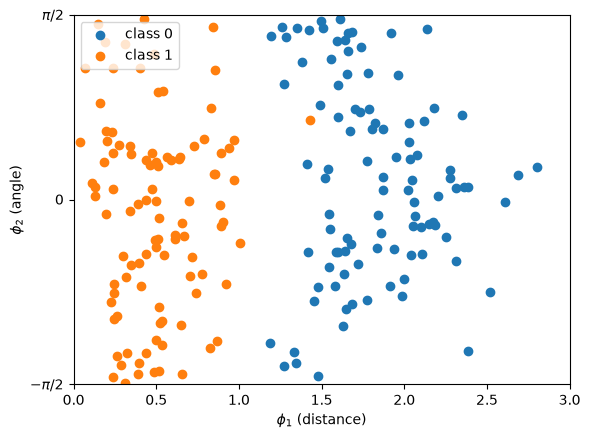

In [12]:
def transform_features(X):
    """Replace the features by their polar coordinates.

    Args:
        X: Data matrix of shape (N, D).

    Returns:
        The transformed data matrix, of shape (N, D).
    """
    radius = np.sqrt(X[:, 0] ** 2 + X[:, 1] ** 2)
    angle = np.arctan(X[:, 1] / X[:, 0])
    return np.stack([radius, angle], axis=1)


X_train_transformed = transform_features(X_train)
X_test_transformed = transform_features(X_test)

plot_data(
    X_train_transformed,
    y_train,
    xlim=(0, 3),
    ylim=(-np.pi / 2, np.pi / 2),
    xlabel=r"$\phi_1$ (distance)",
    ylabel=r"$\phi_2$ (angle)",
)
plt.yticks([-np.pi / 2, 0, np.pi / 2], [r"$-\pi/2$", r"$0$", r"$\pi/2$"]);


Now the classes look linearly separable.
Let's apply logistic regression on top of the transformed features:

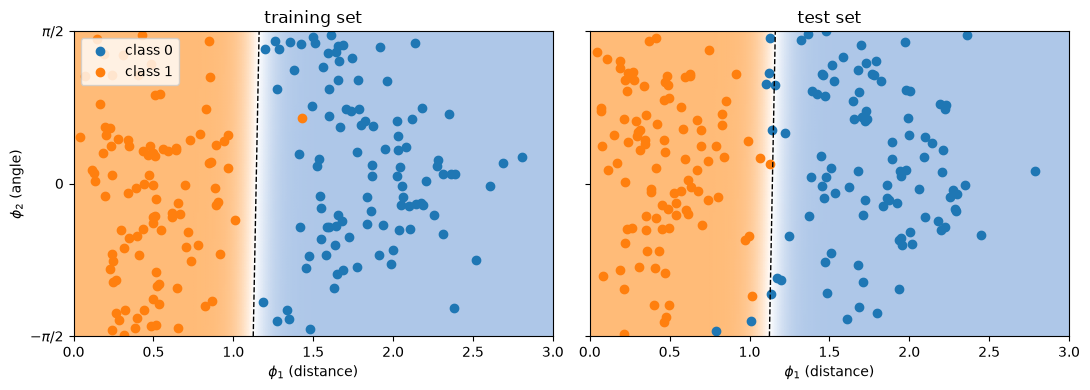

In [13]:
classifier = LogisticRegression(C=np.inf).fit(X_train_transformed, y_train)
theta_sklearn = np.concatenate([classifier.coef_[0], classifier.intercept_])

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharex=True, sharey=True)
sets = [(X_train_transformed, y_train, "training set"), (X_test_transformed, y_test, "test set")]
for panel, (X, y, name) in zip(axes, sets):
    plt.sca(panel)
    plot_boundary(theta_sklearn, xlim=(0, 3), ylim=(-np.pi / 2, np.pi / 2))
    plot_data(
        X,
        y,
        xlim=(0, 3),
        ylim=(-np.pi / 2, np.pi / 2),
        xlabel=r"$\phi_1$ (distance)",
        ylabel=r"$\phi_2$ (angle)",
        legend=panel is axes[0],
    )
    plt.yticks([-np.pi / 2, 0, np.pi / 2], [r"$-\pi/2$", r"$0$", r"$\pi/2$"])
    panel.set_title(name)
    panel.label_outer()  # keep the axis labels on the outer panels only
fig.tight_layout()


We finally found a good solution to our problem.
Note that the boundary is linear in the transformed space, but **non-linear** in the **input space** $\mathbf{x}$: it is an ellipse around the origin.

## Conclusion

We have trained logistic regression in two ways, with our own gradient descent and with scikit-learn, and checked that both find the same parameters once scikit-learn's regularization is off.
Unlike linear regression, neither of them can fall back on a closed-form solution.
We have also seen that a feature transformation can turn a problem that is not linearly separable into one that is.
Finding such a transformation by hand is not an easy task, though.
In the next lectures, we will see how neural networks and support vector machines address this problem.